In [2]:
import pandas as pd
import pandas
import numpy as np
import matplotlib.pyplot as matpyplot
from collections import Counter

In [3]:
# from sklearn.model_selection import train_test_split
# import sklearn as skl
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.metrics import accuracy_score

Hinweis: Mein Ziel ist es den Code so verständlich wie mögliche zu halten. Somit habe ich an manchen Stellen lieber zu viel als zu wenig erklärt. Unter vielen meiner geschriebenen Methoden finden sich auskommentierte "Tests". Sie sollen für jede Methode ein besseres Gefühl vermitteln, wie diese benutzt werden kann. Vor allem aber sollen diese vorbeugen, das man eine Funktion missversteht. Denn nach meiner persönlichen Programmiererfahrung, haben Beispiele noch niemanden geschadet.

Wir deklarieren die entsprechenden 10 Kategorien für unseren Fashion-MNSIT Trainingsdatensatz

In [13]:
LABELS = {
    0: "T-Shirt/Oberteil",
    1: "Hose",
    2: "Pullover",
    3: "Kleid",
    4: "Mantel",
    5: "Sandale",
    6: "Hemd",
    7: "Sneaker",
    8: "Tasche",
    9: "Stiefelette"
}

Wir importieren den Datensatz und geben einen kleinen Auschnitt zur Probe bzw. zur Visualiersung aus

In [14]:
bsp = pd.read_csv("fashion-mnist_train.csv", nrows=10)
bsp.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Wir möchten nun gucken, ob wir die Zeilen der CSV auch in anschauliche Bilder übersetzen können.

Streng genommen bringt dieser Schritt (wie auch der Vorherige) unserem Modell nichts.

Er wird für unser Verständnis aber trotzdem vom Vorteil sein ...


In [15]:
zeile = bsp.iloc[1]         # nimmt die zweite Zeile, also die erste mit kommagetrennten Zahlen
label = zeile.iloc[0]       # nimmt den ersten Wert dieser Spalte, also das Label, welcher Klasse das Kleidungsstück angehört
pixel = zeile.iloc[1:]      # die restlichen 784 kommagetrennten Graustufenwerte [0 bis 255]

Visuelle Ausgabe der kommagetrennten Graustufenwerte als Bild mittels der Bibliothek matplotlib.pyplot

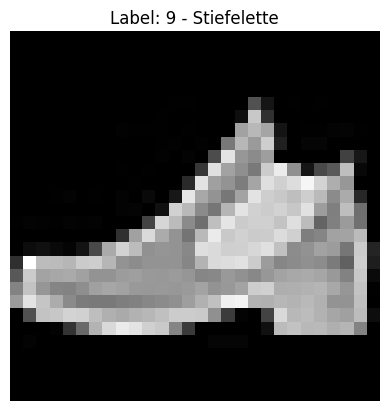

In [16]:
bild = np.array(zeile[1:], dtype=np.uint8).reshape(28,28)         # Um das Bild visualisieren zu können, wandeln wir es in ein 28*28 Array um.
matpyplot.imshow(bild, cmap='gray')
matpyplot.axis("off")
matpyplot.title(f"Label: {label} - {LABELS[label]}")
matpyplot.show()

Nun möchten wir das Bild in 16 Farbgruppen mit je 16 Graustufen unterteilen ~> {{0, ... , 15}, ... , {240, ... , 255}}

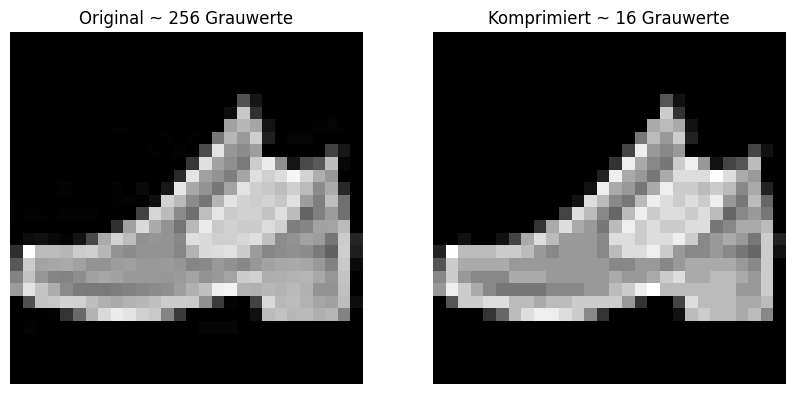

In [17]:
# Dieser Codeblock wurde mit KI generiert
bild_transformed = (bild / 16).astype(np.uint8)
fig, axes = matpyplot.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(bild, cmap='gray', vmin=0, vmax=255)
axes[0].axis("off")
axes[0].set_title(f"Original ~ 256 Grauwerte")
axes[1].imshow(bild_transformed, cmap='gray', vmin=0, vmax=15)
axes[1].axis("off")
axes[1].set_title("Komprimiert ~ 16 Grauwerte")
matpyplot.show()

Wir sehen also, wenn auch nur an einem Beispiel, das wird das Bild anscheinend für die (menschliche) Klassifikationsbeurteilung verlustfrei, komprimieren können. Das machen wir natürlich nicht um Speicherplatz zu sparen, denn das Bild ist bereits sehr klein. Aber dadurch können wir den Rechenaufwand beim Ausführen der Random Trees drastisch reduzieren. Auch für andere Klassifikationsmethoden könnte eine solche Methode hilfreich sein.

---

Nun kommen wir zum Klassifikationsteil, also der Lösung des ursprünglichen Problems

---

Wir definieren hier die Funktion um die Pixel in die 8 bzw. 16 bzw. 32 Gruppen der Graustufen einzuordnen - Man könnte bei noch mehr Gruppierungen auch alle in eine zusammenfassen.

In [18]:
def group_8(data):
    data.iloc[:, 1:] = (data.iloc[:, 1:] // 8).astype(int)
    return data

In [11]:
def group_16(data):
    data.iloc[:, 1:] = (data.iloc[:, 1:] // 16).astype(int)
    return data

In [19]:
def group_32(data):
    data.iloc[:, 1:] = (data.iloc[:, 1:] // 32).astype(int)
    return data

In [20]:
group_16(bsp)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,0,0,...,0,0,0,1,2,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,8,0,0,0,0,0,0,0,0,0,...,12,13,10,0,0,0,0,0,0,0


-----

Diese folgende einfache "bootstrap" Funktion erlaubt es uns, die für die Konstruktion eines random Forests notwendigen zufällig durchgemischten Trainingsdatensätze mittels Bootstrapping zu erzeugen. Anhand jener Datensätze baut man dann pro Datensatz ein Baum.

In [21]:
def bootstrap(data, rows):
    return data.sample(n = rows, replace = True)

In [22]:
bootstrap(bsp, 10)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
9,8,0,0,0,0,0,0,0,0,0,...,12,13,10,0,0,0,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,8,0,0,0,0,0,0,0,0,0,...,12,13,10,0,0,0,0,0,0,0
9,8,0,0,0,0,0,0,0,0,0,...,12,13,10,0,0,0,0,0,0,0
5,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,8,0,0,0,0,0,0,0,0,0,...,12,13,10,0,0,0,0,0,0,0
8,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,0,0,...,0,0,0,1,2,0,0,0,0,0


In [23]:
train = pd.read_csv("fashion-mnist_train.csv")
train = group_16(train)
xTrain = train.iloc[:, 1:]    # wählt alle (784) kommagetrennten Werte außer dem ersten aus.
yTrain = train.iloc[:, 0]     # wählt nur die Klassifikationsziffer aus.

test = pd.read_csv("fashion-mnist_test.csv")
test = group_16(test)
xTest = test.iloc[:, 1:]    # wählt alle (784) kommagetrennten Werte außer dem ersten aus.
yTest = test.iloc[:, 0]     # wählt nur die Klassifikationsziffer aus.

In [125]:
#counts = yTrain.value_counts().reindex(range(10), fill_value=0)
#result_vector = counts.values
#print(result_vector)

---
Random Forest
---
---


In [24]:
B_trees = 100  # Anzahl der Bäume - 100 ist ein guter Startwert, wird je nach Rechenkomplexität der Daten auch gerne auf 300-500 oder sogar 1000 erhöht
m_features = int(np.sqrt(xTrain.shape[1]))  # Ist als HYPERPARAMETER Standardmäßig die Wurzel der Features, da wir hier 28*28 haben also = 28
n_trainDataSets = xTrain.shape[0]
# Anzahl der ausgewerteten Datensätze
# In unserem Fall 60.000 - Aber nicht in der gleichen Variation wie das Original, sonder bootstrapped, also wild durchmischt (inkl. Duplikate, ...)

trees = []

### Todo

In [25]:
"""
print(B_trees)
print(m_features)
print(n_trainDataSets)
"""

60000


In [26]:
def gini(y):
    counts = np.bincount(y)
    probs = counts / len(y)
    return 1.0 - np.sum(probs ** 2)

In [7]:
'''

print(f"1. Pure (All 0s): {gini([0, 0, 0, 0])}")
print(f"2. Balanced (Two classes): {gini([0, 0, 1, 1])}")
print(f"3. Mostly 0: {gini([0, 0, 0, 0, 1])}")
print(f"4. Even Split (Four classes): {gini([0, 1, 2, 3])}")
print(f"5. Random Mix: {gini([0, 0, 1, 2, 2, 2, 3,5,5,5,5,5,5])}")

'''

1. Pure (All 0s): 0.0
2. Balanced (Two classes): 0.5
3. Mostly 0: 0.31999999999999984
4. Even Split (Four classes): 0.75
5. Random Mix: 0.6982248520710059


In [ ]:
def majority_class(y):
    return Counter(y).most_common(1)[0][0]

Falls die prediction folgend None ist, handelt es sich um einen LEAF Node

In [128]:
class TreeNode:
    def __init__(self):
        self.feature = None
        self.threshold = None
        self.left = None
        self.right = None
        self.prediction = None

In [129]:
class DecisionTree:
    def __init__(self, max_depth=10, min_samples_split=2, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.root = None

In [130]:
    """
    def best_split(self, X, y):
        n_samples, n_features = X.shape
        best_gain = 0
        best_feature, best_threshold = None, None

        parent_gini = gini(y)

        features = np.arange(n_features)
        if self.max_features is not None:
            features = np.random.choice(
                n_features,
                self.max_features,
                replace=False
            )

        for feature in features:
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask


                # Avoid splits where all samples go to one side.
                # Such splits give no information gain
                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                y_left = y[left_mask]
                y_right = y[right_mask]

                gain = parent_gini - (
                    len(y_left) / n_samples * gini(y_left)
                    + len(y_right) / n_samples * gini(y_right)
                )

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold
    """

In [131]:
def best_split(self, X, y):
    n_samples, n_features = X.shape
    best_gain = 0
    best_feature, best_threshold = None, None

    parent_gini = gini(y)

    features = np.arange(n_features)
    if self.max_features is not None:
        features = np.random.choice(
            n_features,
            self.max_features,
            replace=False
        )

    for feature in features:
        thresholds = np.unique(X[:, feature])
        for threshold in thresholds:
            left_mask = X[:, feature] <= threshold
            right_mask = ~left_mask

            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue

            y_left = y[left_mask]
            y_right = y[right_mask]

            gain = parent_gini - (
                len(y_left) / n_samples * gini(y_left)
                + len(y_right) / n_samples * gini(y_right)
            )

            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold

In [132]:
def build_tree(self, X, y, depth):
    node = TreeNode()

    if (
        depth >= self.max_depth
        or len(y) < self.min_samples_split
        or len(np.unique(y)) == 1
    ):
        node.prediction = majority_class(y)
        return node

    feature, threshold = self.best_split(X, y)

    if feature is None:
        node.prediction = majority_class(y)
        return node

    node.feature = feature
    node.threshold = threshold

    left_mask = X[:, feature] <= threshold
    right_mask = ~left_mask

    node.left = self.build_tree(X[left_mask], y[left_mask], depth + 1)
    node.right = self.build_tree(X[right_mask], y[right_mask], depth + 1)

    return node


In [133]:
def fit(self, X, y):
    self.root = self.build_tree(X, y, 0)

def predict_one(self, x, node):
    if node.prediction is not None:
        return node.prediction
    if x[node.feature] <= node.threshold:
        return self.predict_one(x, node.left)
    else:
        return self.predict_one(x, node.right)

def predict(self, X):
    return np.array([self.predict_one(x, self.root) for x in X])


In [134]:
class RandomForest:
    def __init__(self, n_estimators=10, max_depth=10, min_samples_split=2):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        max_features = int(np.sqrt(n_features))

        for _ in range(self.n_estimators):
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_boot = X[indices]
            y_boot = y[indices]

            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=max_features
            )
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)

    def predict(self, X):
        all_preds = np.array([tree.predict(X) for tree in self.trees])
        return np.array([
            Counter(all_preds[:, i]).most_common(1)[0][0]
            for i in range(X.shape[0])
        ])



In [135]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


def class_wise_accuracy(y_true, y_pred, n_classes=10):
    acc = {}
    for c in range(n_classes):
        mask = y_true == c
        acc[c] = np.mean(y_pred[mask] == y_true[mask])
    return acc

In [136]:
class DecisionTree:
    def __init__(self, max_depth=10, min_samples_split=2, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.root = None

    def best_split(self, X, y):
        n_samples, n_features = X.shape
        best_gain = 0
        best_feature, best_threshold = None, None

        parent_gini = gini(y)

        features = np.arange(n_features)
        if self.max_features is not None:
            features = np.random.choice(
                n_features, self.max_features, replace=False
            )

        for feature in features:
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask

                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                y_left = y[left_mask]
                y_right = y[right_mask]

                gain = parent_gini - (
                    len(y_left) / n_samples * gini(y_left)
                    + len(y_right) / n_samples * gini(y_right)
                )

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def build_tree(self, X, y, depth):
        node = TreeNode()

        if (
            depth >= self.max_depth
            or len(y) < self.min_samples_split
            or len(np.unique(y)) == 1
        ):
            node.prediction = majority_class(y)
            return node

        feature, threshold = self.best_split(X, y)

        if feature is None:
            node.prediction = majority_class(y)
            return node

        node.feature = feature
        node.threshold = threshold

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        node.left = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        node.right = self.build_tree(X[right_mask], y[right_mask], depth + 1)

        return node

    def fit(self, X, y):
        self.root = self.build_tree(X, y, 0)

    def predict_one(self, x, node):
        if node.prediction is not None:
            return node.prediction
        if x[node.feature] <= node.threshold:
            return self.predict_one(x, node.left)
        else:
            return self.predict_one(x, node.right)

    def predict(self, X):
        return np.array([self.predict_one(x, self.root) for x in X])


In [137]:
class RandomForest:
    def __init__(self, n_estimators=10, max_depth=10, min_samples_split=2):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        max_features = int(np.sqrt(n_features))

        for _ in range(self.n_estimators):
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_boot = X[indices]
            y_boot = y[indices]

            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=max_features
            )
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)

    def predict(self, X):
        all_preds = np.array([tree.predict(X) for tree in self.trees])
        return np.array([
            Counter(all_preds[:, i]).most_common(1)[0][0]
            for i in range(X.shape[0])
        ])


In [138]:
tree = DecisionTree()
print(hasattr(tree, "fit"), hasattr(tree, "predict"))

rf = RandomForest()
print(hasattr(rf, "fit"), hasattr(rf, "predict"))


True True
True True


In [139]:
rf = RandomForest(
    n_estimators=10,
    max_depth=10,
    min_samples_split=5
)

xTrain = np.asarray(xTrain)
yTrain = np.asarray(yTrain)
xTest  = np.asarray(xTest)
yTest  = np.asarray(yTest)

rf.fit(xTrain, yTrain)

yPred = rf.predict(xTest)

print("Overall accuracy:", accuracy(yTest, yPred))

class_acc = class_wise_accuracy(yTest, yPred)
print("Class-wise accuracy:")
for cls, acc in class_acc.items():
    print(f"Class {cls}: {acc:.3f}")

Overall accuracy: 0.8412
Class-wise accuracy:
Class 0: 0.821
Class 1: 0.950
Class 2: 0.729
Class 3: 0.907
Class 4: 0.812
Class 5: 0.899
Class 6: 0.501
Class 7: 0.897
Class 8: 0.963
Class 9: 0.933
